### Replicating the music brainz dataset with splink for checking
Previous experiments were done with artificial data generated with a specific ruleset in mind, which supported splink usage. We attempt to replicate the results we have in the previous attempt with a public dataset, to 

1) replicate QR3's results 
2) identify potential edge cases/situations where splink might not be enough for global assignment

In [1]:
import pandas as pd

import os, sys

# ---- 1️⃣ Find the directory that holds the `em_pipeline` package ----
# Start from the notebook’s directory (or the current working directory)
start = os.path.abspath(os.getcwd())
if "__file__" in globals():                     # works when run as a script
    start = os.path.abspath(os.path.dirname(__file__))

# Walk up the tree until we see a folder called `em_pipeline`
repo_root = start
while True:
    if os.path.isdir(os.path.join(repo_root, "em_pipeline")):
        break                                   # we found it
    parent = os.path.dirname(repo_root)
    if parent == repo_root:                     # reached filesystem root → give up
        raise RuntimeError("Could not find a directory containing 'em_pipeline'")
    repo_root = parent

# ---- 2️⃣ Insert it at the front of sys.path (if not already there) ----
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


from em_pipeline.data_loader import load_pair_dfs_from_paths, standardise_dt
from em_pipeline.splink_helper import (
    build_api_with_con,
    get_blocking_rules,
    get_estimating_blocking_rules,
    get_numerical_comparison,
    get_datetime_comparison,
    get_category_comparison,
    train_linker,
    visualise_data,
)
from splink import DuckDBAPI, Linker, SettingsCreator

In [2]:
DF_PATH = os.path.join("..", "..", "public_datasets", "musicbrainz-20-A01.csv.dapo")

# DuckDB resource limits (same as in the original notebook)
MEM_LIMIT  = "24GB"
TEMP_DIR   = "./duckdb_spill_dir.tmp"

In [3]:
target_dir = os.path.dirname(DF_PATH)

# Import the files directly
df1 = pd.read_parquet(os.path.join(target_dir, "music3.parq"))
df2 = pd.read_parquet(os.path.join(target_dir, "music5.parq"))

#### Cleaning the dataset, prepping it for splinking

keys for the dataset:
- TID: unique record id -> no real value, just to double check the uniqueness in the dateset and no duping
- CID: cluster ID: this is the main goal for the clustering -> we can repurpose this - cluster ID would work as our ground truth pairing for local matching
- SourceID: the source itself - we just use it for data splitting and cleaning
- ID: the original ID or some nonsense. useless.
- Number: deceptively actually a categorical: is the track/song number in the album
- Length: One of the harder problems to deal with, but not for now. We figure out how to develop some sort of good method to convert song lengths in various representations to a standardised format 
- Artist: Textual comparison 
- Year: Interestingly, also another basis for textual comparison. Note the example below
- Language: Kind of useless...? We can limit it down to pure english songs to compare or something i guess...?

In [3]:
# We think about splitting the datasets into two - and from there we figure out if we can find a reasonable methodology
# for creating a set of viable ground truths
df = pd.read_csv(DF_PATH)

df1 = df[df['SourceID'] == 3].copy()
df2 = df[df['SourceID'] == 5].copy()

In [4]:
common_artists = set(df1['artist']).intersection(set(df2['artist']))
all_artists = set(df1['artist']).union(set(df2['artist']))

# we map them over to df1 and df2
artist_to_uai = {}
for idx, artist in enumerate(common_artists):
    artist_to_uai[artist] = f"uai_{idx}"

# assign subsequenet unique artists
next_id = len(common_artists)
for artist in all_artists - common_artists:
    artist_to_uai[artist] = f"uai_{next_id}"
    next_id += 1

df1['uai'] = df1['artist'].map(artist_to_uai)
df2['uai'] = df2['artist'].map(artist_to_uai)

In [5]:
df1

,TID,CID,CTID,SourceID,id,number,title,length,artist,album,year,language,uai
5,6,5,1,3,49425110MB-01,6,"Try (acoustic) - 2008-02-15: Le Grand Rex, Par...",NaN,Neil Young,NaN,NaN,English,uai_838
20,21,3118,2,3,4763264MB-01,6,Cállate - Los vaqueros: el regreso: Deluxe Edi...,4.367,Wisin & Yandel,NaN,'11,Spanish,uai_13
24,25,5893,2,3,50116112MB-01,9,Fish Tail Blues - The King & Mister Jelly Lord,3.085,Jelly Roll Morton,NaN,'89,English,uai_604
38,39,519,3,3,5235450MB-01,13,Mu sõber tuul - Uus Laine,4.567,Laine,NaN,'00,Estonian,uai_5829
43,44,25,1,3,23433710MB-01,2,Fried Bananas - Live at the Amsterdam Paradiso,12.3,Dexter Gordon,NaN,'94,English,uai_230
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19365,19366,9994,1,3,11546013MB-01,12,Steal Away - Flight of Earls,4.424,Dublin City Ramblers,NaN,NaN,English,uai_567
19367,19368,9995,1,3,14504822MB-01,4,I Am What I Am (live at Abbey Road) - Clementine,4.374,Mark Owen,NaN,NaN,English,uai_5985
19369,19370,9996,1,3,70007517MB-01,9,Sukkana alas! - Kans'an Popeda,2.928,Popeda,NaN,'05,Finnish,uai_2780
19371,19372,9998,1,3,37406511MB-01,5,The Pressure of Pitching Doves - Run on Anything,1.85,Buddy Wakefield,NaN,NaN,English,uai_5179


In [6]:
df2

,TID,CID,CTID,SourceID,id,number,title,length,artist,album,year,language,uai
3,4,3,1,5,4489993,10,Your Grace,unk.,Kathy Troccoli,Comfort,2005,English,uai_4269
4,5,4,1,5,10339621,2,Well You Needn't,321266,Ernie Stadler Jazz Quintet,First Down,2010,English,uai_1397
8,9,7,1,5,10992441,9,Just Like Tom Thumb's Blues (live),462000,Wendy Saddington,"Blues Women Anthology, Volume 7",2007,English,uai_299
9,10,6842,4,5,15761001,4,Στα καμένα,195000,Λαυρέντης Μαχαιρίίτσας,"Συλλογή Δίφωνο, 22: Μουσικοί βιότοποι",1997,Greek,uai_4401
10,11,5568,2,5,855829,6,NaN,188400,Anathema,Alternative 4,1998,English,uai_4117
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19318,19319,2898,5,5,3435746,1,"Inside the Dream Syndicate, Volume I: Day of N...",1854000,"John Cale, Tony Conrad, Angus MacLise, La Mont...","Inside the Dream Syndicate, Volume I: Day of N...",2000,English,uai_517
19327,19328,9974,1,5,9839750,4,Wedding,334000,Charbel Rouuhana,fma Festival du Monde Arabe de Montréal 10ième...,NaN,French,uai_2335
19331,19332,4851,2,5,12382038,9,"Just You, Just Me",296000,Sonny Stitt & Barry Harris,The Complete Late Quartets,2010,English,uai_1870
19332,19333,4920,2,5,6817983,5,Nightmare,NaN,Icos,Fragments of Sirens,NaN,English,uai_4087


In [7]:
target_dir = os.path.dirname(DF_PATH)

music3_path = os.path.join(target_dir, "music3.parq")
music5_path = os.path.join(target_dir, "music5.parq")

# 3. Save the DataFrames
df1.to_parquet(music3_path, index=False)
df2.to_parquet(music5_path, index=False)

#### Initial thoughts
we want to essentially record match on the song itself, and then group them by the `artist`. we of course assume there
are no spelling errors in the `artist` column - 


- the crux of the problem is generally the textual matching, and how robust we can make it.
- `number` is deceptive as a column: this is a categorical match.
- `length` is a numerical match - seems to refer to song duration, we just need to clean it.
    the intuition behind the cleaning is problematic though - we have cases of time stored as milliseconds, seconds, and minutes.
    this becomes a rather big problem when we cant immediately establish which it really is
    thinking about a simple approach of clustering them into groups and then deciding what it really is. 
    there are cases, however, of the time stored in various methods. we probably need a robust method to convert the data.
- ``

In [4]:
# We compare number not unsimilarly to the way we compare categoricals.
df1['album'].unique()

array([None, 'Dat Girl', 'Peter en de Wolf',
       'Inside the Dream Syndicate, Volume I: Day of Niagara (1965)',
       'Dil Ka Rishta', "True Love That's a Wonder",
       'Why Did They Sell Killarney?', "Don't Cry for Me Argentina",
       'Coat of Many Colors', 'The American Dream',
       'Wandering Eternal in a Dreamlike State', 'Alwas Loved a Film',
       'Requiem', 'Uncontrllable', "'til You're Numb", 'Inferno', 'Skin',
       'All My Friends Say', 'Comerica - Bruce Wayne: Gothom 1987',
       'C loned', 'Hot Science', 'Winterreise', 'Lieder ohne Worte',
       'Take It', 'Up!', 'Slapstick', 'Get on My Camel', 'Bende Can',
       'Romances sans paroles', 'Les Concerts Royaux', 'Onnelma', 'unk.',
       'words of the mind ～brandnew journey～', 'Pohjantuuli',
       'Haus der Lüge', 'Frealism', 'If You Were Mine', 'unknown',
       'I Have a Vision', 'Bengalische Tiger', 'Subplate', 'Fogbank',
       'デタラメな残像', 'Cœur des Cajuns', "Don't Talk", 'Traneing In',
       'Perfect Day'

In [5]:
df1[df1['artist'] == "Stranglers"]

,TID,CID,CTID,SourceID,id,number,title,length,artist,album,year,language,uai


In [6]:
df2[df2['artist'] == "The Stranglers"]

,TID,CID,CTID,SourceID,id,number,title,length,artist,album,year,language,uai


In [7]:
# We'll do some basic attempt to clean - we notice that in df1, the album is already kept into the title, with a delimiter
# df1 does have cases of having album filled, so what we do is: in the case where album isnt filled, and title has the
# delimiter, we just split that by string and throw it into the album as the album name.

df1_clean = df1.copy()

# Ensure we handle Python None, empty strings, or string 'None' safely
df1_clean['album'] = df1_clean['album'].replace({'None': None, '': None})

# Identify where the album column is missing/None AND a delimiter exists in the title
needs_split = df1_clean['album'].isna() & df1_clean['title'].str.contains(r"\s-\s", regex=True, na=False)

# Perform the split from the RIGHT hand side (last occurrence only)
# expand=True gives a 2-column DataFrame
right_split = df1_clean.loc[needs_split, 'title'].str.rsplit(r" - ", n=1, expand=True)

# Assign the split outputs back to their respective columns
df1_clean.loc[needs_split, 'title'] = right_split[0].str.strip()
df1_clean.loc[needs_split, 'album'] = right_split[1].str.strip()

# Standardize IDs and whitespace tracking for Splink
df1_clean = df1_clean.rename(columns={'id': 'unique_id'})
df1_clean['title'] = df1_clean['title'].str.strip()
df1_clean['artist'] = df1_clean['artist'].str.strip()

# --- Align DF2 Schema ---
df2_clean = df2.copy()
df2_clean = df2_clean.rename(columns={'id': 'unique_id'})
df2_clean['title'] = df2_clean['title'].str.strip()
df2_clean['artist'] = df2_clean['artist'].str.strip()
df2_clean['album'] = df2_clean['album'].str.strip()


In [8]:
import pandas as pd
import numpy as np

def clean_music_data_with_years(df, is_df1=True):
    df_clean = df.copy()
    df_clean = df_clean.rename(columns={'id': 'unique_id'})
    
    # Standardize string representations
    for col in ['title', 'artist', 'album', 'year']:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.strip().replace({'None': None, '': None, 'nan': None})

    # Length Conversion (df1: minutes to ms | df2: keep as is)
    if is_df1:
        df_clean['length_ms'] = pd.to_numeric(df_clean['length'], errors='coerce') * 60 * 1000
    else:
        df_clean['length_ms'] = pd.to_numeric(df_clean['length'], errors='coerce')

    # Year Array Logic: Generate both centuries for 2-digit ambiguity
    def get_possible_years(y):
        if pd.isna(y): 
            return None
        s = str(y).replace("'", "").strip()
        if not s.isdigit(): 
            return None
        
        val = int(s)
        if len(s) <= 2:
            # Output a python list containing BOTH structural options
            return [1900 + val, 2000 + val]
        else:
            return [val]

    df_clean['year_options'] = df_clean['year'].apply(get_possible_years)
    return df_clean

# Run the aligned pipeline
df1_clean = clean_music_data_with_years(df1_clean, is_df1=True)
df2_clean = clean_music_data_with_years(df2_clean, is_df1=False)


In [9]:
for df in [df1_clean, df2_clean]:
    # 1. Convert string versions of 'None' or 'nan' to true numeric NaNs
    df['artist'] = df['artist'].astype(str).str.strip().replace({'None': np.nan, 'nan': np.nan})
    df['title'] = df['title'].astype(str).str.strip().replace({'None': np.nan, 'nan': np.nan})
    
    # 2. Enforce absolute numeric processing on Track Numbers
    # Invalid or text track numbers gracefully drop to NaN
    df['number'] = pd.to_numeric(df['number'], errors='coerce')

In [10]:
df1_clean

,TID,CID,CTID,SourceID,unique_id,number,title,length,artist,album,year,language,uai,length_ms,year_options
0,6,5,1,3,49425110MB-01,6.0,Try (acoustic),None,Neil Young,"2008-02-15: Le Grand Rex, Paris, France",None,English,uai_838,NaN,None
1,21,3118,2,3,4763264MB-01,6.0,Cállate,4.367,Wisin & Yandel,Los vaqueros: el regreso: Deluxe Edition,'11,Spanish,uai_13,262020.0,"[1911, 2011]"
2,25,5893,2,3,50116112MB-01,9.0,Fish Tail Blues,3.085,Jelly Roll Morton,The King & Mister Jelly Lord,'89,English,uai_604,185100.0,"[1989, 2089]"
3,39,519,3,3,5235450MB-01,13.0,Mu sõber tuul,4.567,Laine,Uus Laine,'00,Estonian,uai_5829,274020.0,"[1900, 2000]"
4,44,25,1,3,23433710MB-01,2.0,Fried Bananas,12.3,Dexter Gordon,Live at the Amsterdam Paradiso,'94,English,uai_230,738000.0,"[1994, 2094]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3921,19366,9994,1,3,11546013MB-01,12.0,Steal Away,4.424,Dublin City Ramblers,Flight of Earls,None,English,uai_567,265440.0,None
3922,19368,9995,1,3,14504822MB-01,4.0,I Am What I Am (live at Abbey Road),4.374,Mark Owen,Clementine,None,English,uai_5985,262440.0,None
3923,19370,9996,1,3,70007517MB-01,9.0,Sukkana alas!,2.928,Popeda,Kans'an Popeda,'05,Finnish,uai_2780,175680.0,"[1905, 2005]"
3924,19372,9998,1,3,37406511MB-01,5.0,The Pressure of Pitching Doves,1.85,Buddy Wakefield,Run on Anything,None,English,uai_5179,111000.0,None


In [11]:
df2_clean

,TID,CID,CTID,SourceID,unique_id,number,title,length,artist,album,year,language,uai,length_ms,year_options
0,4,3,1,5,4489993,10.0,Your Grace,unk.,Kathy Troccoli,Comfort,2005,English,uai_4269,NaN,[2005]
1,5,4,1,5,10339621,2.0,Well You Needn't,321266,Ernie Stadler Jazz Quintet,First Down,2010,English,uai_1397,321266.0,[2010]
2,9,7,1,5,10992441,9.0,Just Like Tom Thumb's Blues (live),462000,Wendy Saddington,"Blues Women Anthology, Volume 7",2007,English,uai_299,462000.0,[2007]
3,10,6842,4,5,15761001,4.0,Στα καμένα,195000,Λαυρέντης Μαχαιρίίτσας,"Συλλογή Δίφωνο, 22: Μουσικοί βιότοποι",1997,Greek,uai_4401,195000.0,[1997]
4,11,5568,2,5,855829,6.0,NaN,188400,Anathema,Alternative 4,1998,English,uai_4117,188400.0,[1998]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3823,19319,2898,5,5,3435746,1.0,"Inside the Dream Syndicate, Volume I: Day of N...",1854000,"John Cale, Tony Conrad, Angus MacLise, La Mont...","Inside the Dream Syndicate, Volume I: Day of N...",2000,English,uai_517,1854000.0,[2000]
3824,19328,9974,1,5,9839750,4.0,Wedding,334000,Charbel Rouuhana,fma Festival du Monde Arabe de Montréal 10ième...,None,French,uai_2335,334000.0,None
3825,19332,4851,2,5,12382038,9.0,"Just You, Just Me",296000,Sonny Stitt & Barry Harris,The Complete Late Quartets,2010,English,uai_1870,296000.0,[2010]
3826,19333,4920,2,5,6817983,5.0,Nightmare,None,Icos,Fragments of Sirens,None,English,uai_4087,NaN,None


In [12]:
target_dir = os.path.dirname(DF_PATH)

clean_music3_path = os.path.join(target_dir, "cleaned_music3.parq")
clean_music5_path = os.path.join(target_dir, "cleaned_music5.parq")

# 3. Save the DataFrames
df1_clean.to_parquet(clean_music3_path, index=False)
df2_clean.to_parquet(clean_music5_path, index=False)

In [13]:
import splink.comparison_library as cl
import splink.comparison_level_library as cll
from splink import SettingsCreator

import splink.comparison_library as cl
import splink.comparison_level_library as cll
from splink import SettingsCreator, DuckDBAPI, Linker

import splink.comparison_library as cl
import splink.comparison_level_library as cll
from splink import SettingsCreator, DuckDBAPI, Linker

# ==============================================================================
# 1. TEXT COMPARISONS (Using _l and _r Suffixes)
# ==============================================================================

artist_comparison = cl.CustomComparison(
    output_column_name="artist",
    comparison_levels=[
        cll.NullLevel("artist"),
        cll.ExactMatchLevel("artist"),
        cll.JaroWinklerLevel("artist", distance_threshold=0.88),
        cll.ElseLevel()
    ]
)

title_lexical_comparison = cl.CustomComparison(
    output_column_name="title_lexical",
    comparison_levels=[
        cll.NullLevel("title"),
        cll.ExactMatchLevel("title"),
        # FIXED: Changed l.title -> title_l and r.title -> title_r
        {
            "sql_condition": "title_l LIKE title_r || '%' OR title_r LIKE title_l || '%'",
            "label_for_charts": "One title is a prefix of the other"
        },
        cll.JaroWinklerLevel("title", distance_threshold=0.90),
        cll.ElseLevel()
    ]
)

title_token_comparison = cl.CustomComparison(
    output_column_name="title_tokens",
    comparison_levels=[
        cll.NullLevel("title"),
        cll.JaccardLevel("title", distance_threshold=0.80),
        cll.JaccardLevel("title", distance_threshold=0.55),
        cll.ElseLevel()
    ]
)

album_comparison = cl.CustomComparison(
    output_column_name="album",
    comparison_levels=[
        cll.NullLevel("album"),
        cll.ExactMatchLevel("album"),
        # FIXED: Changed l.album -> album_l and r.album -> album_r
        {
            "sql_condition": "album_l LIKE album_r || '%' OR album_r LIKE album_l || '%'",
            "label_for_charts": "Album truncation match"
        },
        cll.ElseLevel()
    ]
)

# ==============================================================================
# 2. NUMERIC AND ARRAY COMPARISONS (Using _l and _r Suffixes)
# ==============================================================================

length_comparison = cl.CustomComparison(
    output_column_name="length_ms",
    comparison_levels=[
        cll.NullLevel("length_ms"),
        # FIXED: Changed to length_ms_l and length_ms_r
        {
            "sql_condition": "length_ms_l >= length_ms_r * 0.85 AND length_ms_l <= length_ms_r * 1.15",
            "label_for_charts": "Length match within 15%"
        },
        {
            "sql_condition": "length_ms_l >= length_ms_r * 0.60 AND length_ms_l <= length_ms_r * 1.40",
            "label_for_charts": "Length match within 40%"
        },
        cll.ElseLevel()
    ]
)

# Standardized year list check using clean native DuckDB list operations
year_array_comparison = cl.CustomComparison(
    output_column_name="year_options",
    comparison_levels=[
        cll.NullLevel("year_options"),
        {
            "sql_condition": "len(list_intersect(year_options_l, year_options_r)) > 0",
            "label_for_charts": "Exact year option intersect"
        },
        # FIXED: Swapped out list_cross_product for native range expansion
        {
            "sql_condition": """
                list_has_any(
                    flatten(list_transform(year_options_l, x -> range(x - 2, x + 3))), 
                    year_options_r
                )
            """,
            "label_for_charts": "Year options within 2-year drift"
        },
        cll.ElseLevel()
    ]
)

# ==============================================================================
# CONSOLIDATED SETTINGS BLOCK
# ==============================================================================
blocking_rules = [
    # Rule 1: Same Artist AND Same Track Number
    # Highly selective. Filters down immediately to the specific track slot.
    """
    (l.artist = r.artist AND l.number = r.number)
    """,
    
    # Rule 2: Same Track Number AND Same Title Prefix (Extended to 6 chars)
    # Removing language forces the title match to do the heavy lifting.
    # Extending to 6 characters breaks down common words like "The Be..." vs "The Bl..."
    """
    (l.number = r.number AND SUBSTR(l.title, 1, 6) = SUBSTR(r.title, 1, 6))
    """,
    
    # Rule 3: Exact Artist Match AND Title Prefix Match
    # For tracks where track numbers are missing/None or mismatched (e.g. bonus tracks)
    """
    (l.artist = r.artist AND SUBSTR(l.title, 1, 4) = SUBSTR(r.title, 1, 4))
    """
]


settings = SettingsCreator(
    link_type="link_only",
    comparisons=[
        artist_comparison,
        title_lexical_comparison,
        title_token_comparison,
        album_comparison,
        length_comparison,
        
        # Robust multi-century year matching
        year_array_comparison,
        
        cl.ExactMatch("number"),
    ],
    # Inclusive blocking filters to prevent discarding unmatched null fields
    blocking_rules_to_generate_predictions=blocking_rules,
    unique_id_column_name="CID",
    retain_intermediate_calculation_columns=True,
    additional_columns_to_retain=["CID", "CTID", "uai"],
)


In [14]:
MEM_LIMIT  = "'24GB'"
TEMP_DIR   = "'./duckdb_spill_dir.tmp'"

db_api = build_api_with_con(MEM_LIMIT, TEMP_DIR)

In [15]:
from splink.blocking_analysis import (
    cumulative_comparisons_to_be_scored_from_blocking_rules_chart
)


cumulative_comparisons_to_be_scored_from_blocking_rules_chart(
    table_or_tables=[df1_clean, df2_clean],
    blocking_rules=blocking_rules,
    db_api=db_api,
    link_type="link_only",
    unique_id_column_name="CID",
    max_rows_limit=200000000000
)

alt.Chart(...)

In [16]:
db_api = build_api_with_con(MEM_LIMIT, TEMP_DIR)

linker = Linker(
    [df1_clean, df2_clean],
    settings,
    db_api=db_api
)

In [17]:
def get_estimating_blocking_rules():
    """
    Returns the initial loose blocking rule to estimate the overall 
    global probability that two random records chosen by the index match.
    """
    return ["l.artist = r.artist AND l.number = r.number"]

def train_music_linker_em(linker, recall=0.95):
    """
    Executes unsupervised Expectation-Maximization training on the music dataset.
    Trains individual feature weights across independent structural dimensions.
    """
    print("Initializing Unsupervised EM Training...")
    
    # 1. Estimate the baseline proportion of true matches in the blocked subset
    linker.training.estimate_probability_two_random_records_match(
        get_estimating_blocking_rules(), 
        recall=recall
    )
    
    # 2. Estimate the 'u' probabilities (coincidental matches) via random sampling
    linker.training.estimate_u_using_random_sampling(max_pairs=int(1e8))
    
    # 3. EM Training Block 1: Lock down Number, Artist, and Title prefix
    # Establishes the weights for: length_ms, album, and year_options
    print("Running EM Session 1 (Training: Length, Album, Year)...")
    block_1_sql = """
        l.number = r.number 
        AND l.artist = r.artist 
        AND l.artist != 'None'
        AND SUBSTR(l.title, 1, 5) = SUBSTR(r.title, 1, 5)
    """
    linker.training.estimate_parameters_using_expectation_maximisation(block_1_sql)
    
    # 4. EM Training Block 2: Lock down Length delta, Album match, and Fuzzy Year drift
    # Establishes the weights for: artist, title_lexical, title_tokens, number
    print("Running EM Session 2 (Training: Artist, Titles, Number)...")
    
    # FIXED: Uses native DuckDB flattening & transformation arrays to test the +/- 2 year window
    # Generates a sequence from (year - 2) to (year + 2) for every element in list L,
    # then checks if list R overlaps with any of those valid historical years.
    fuzzy_year_condition = """
        list_has_any(
            flatten(list_transform(l.year_options, x -> range(x - 2, x + 3))), 
            r.year_options
        )
    """
    
    block_2_sql = f"""
        ABS(l.length_ms - r.length_ms) <= 10000 
        AND l.album = r.album 
        AND l.album != 'None'
        AND ({fuzzy_year_condition})
    """
    linker.training.estimate_parameters_using_expectation_maximisation(block_2_sql)
    
    print("Unsupervised EM Training Complete.")


In [18]:
# Execute the unsupervised parameter calculations
train_music_linker_em(linker, recall=0.95)

# Run the inference engine across your data candidates
print("Computing final match predictions...")
predictions_df = linker.inference.predict()

# Convert out to standard Pandas for evaluation
df_results = predictions_df.as_pandas_dataframe()


Probability two random records match is estimated to be  6.73e-05.
This means that amongst all possible pairwise record comparisons, one in 14,856.70 are expected to match.  With 15,028,728 total possible comparisons, we expect a total of around 1,011.58 matching pairs
----- Estimating u probabilities using random sampling -----


Initializing Unsupervised EM Training...



Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - artist (no m values are trained).
    - title_lexical (no m values are trained).
    - title_tokens (no m values are trained).
    - album (no m values are trained).
    - length_ms (no m values are trained).
    - year_options (no m values are trained).
    - number (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

        l.number = r.number 
        AND l.artist = r.artist 
        AND l.artist != 'None'
        AND SUBSTR(l.title, 1, 5) = SUBSTR(r.title, 1, 5)
    

Parameter estimates will be made for the following comparison(s):
    - album
    - length_ms
    - year_options

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - artist
    - title_lexical
    - title_tokens
    - number

Iteration 1: Largest change in params

Running EM Session 1 (Training: Length, Album, Year)...


Iteration 2: Largest change in params was 8.3e-06 in the m_probability of year_options, level `All other comparisons`

EM converged after 2 iterations

Your model is not yet fully trained. Missing estimates for:
    - artist (no m values are trained).
    - title_lexical (no m values are trained).
    - title_tokens (no m values are trained).
    - number (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

        ABS(l.length_ms - r.length_ms) <= 10000 
        AND l.album = r.album 
        AND l.album != 'None'
        AND (
        list_has_any(
            flatten(list_transform(l.year_options, x -> range(x - 2, x + 3))), 
            r.year_options
        )
    )
    

Parameter estimates will be made for the following comparison(s):
    - artist
    - title_lexical
    - title_tokens
    - number

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking r

Running EM Session 2 (Training: Artist, Titles, Number)...


Iteration 3: Largest change in params was 1.04e-05 in the m_probability of title_tokens, level `All other comparisons`

EM converged after 3 iterations

Your model is fully trained. All comparisons have at least one estimate for their m and u values
Blocking time: 0.07 seconds


Unsupervised EM Training Complete.
Computing final match predictions...


Predict time: 0.17 seconds


In [19]:
linker.visualisations.match_weights_chart()

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

### 

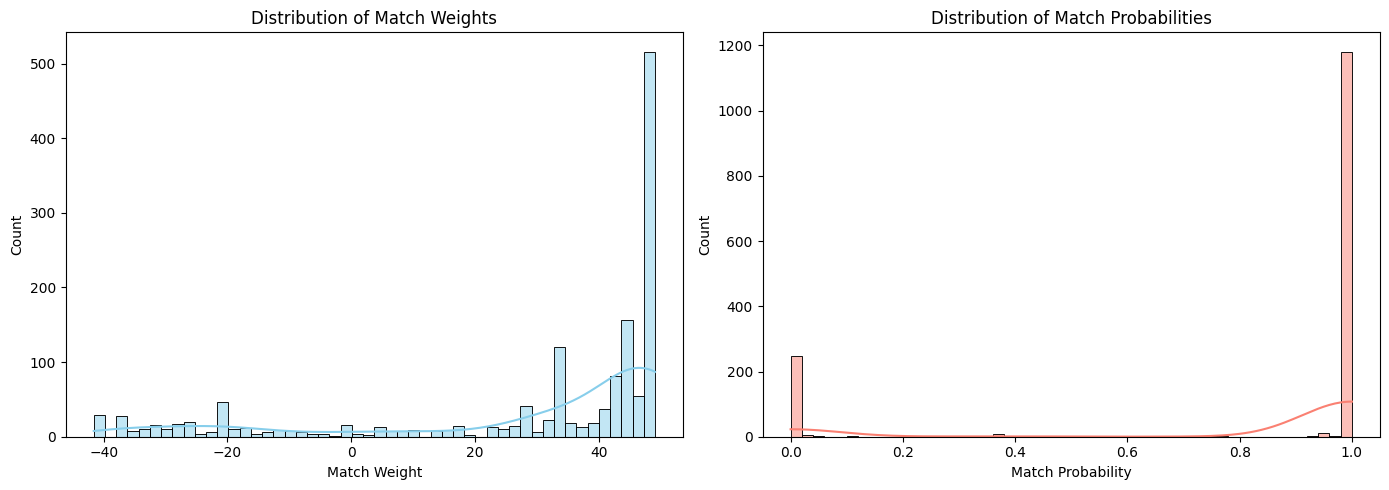

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the Splink object is converted to a Pandas DataFrame
df_pandas = df_results

# Create a two-panel distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution (Linear scale, e.g., -10 to +30)
sns.histplot(data=df_pandas, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=df_pandas, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()

In [21]:
df_results

,match_weight,match_probability,source_dataset_l,source_dataset_r,CID_l,CID_r,artist_l,artist_r,gamma_artist,bf_artist,...,bf_year_options,number_l,number_r,gamma_number,bf_number,CTID_l,CTID_r,uai_l,uai_r,match_key
0,49.089737,1.000000e+00,__splink__input_table_0,__splink__input_table_1,7,7,Wendy Saddington,Wendy Saddington,2,4602.444889,...,24.623950,9.0,9.0,1,16.863659,4,1,uai_299,uai_299,0
1,47.640098,1.000000e+00,__splink__input_table_0,__splink__input_table_1,6842,6842,Λαυρέντης Μαχαιρίτσας,Λαυρέντης Μαχαιρίίτσας,1,1685.015295,...,24.623950,4.0,4.0,1,16.863659,2,4,uai_1893,uai_4401,1
2,45.633213,1.000000e+00,__splink__input_table_0,__splink__input_table_1,3385,3385,Diana Ross & Lionel Richie,Diana Ross & Lionel Richie,2,4602.444889,...,24.623950,5.0,5.0,1,16.863659,2,4,uai_532,uai_532,0
3,33.451364,1.000000e+00,__splink__input_table_0,__splink__input_table_1,7301,7301,Doors,The Doros,0,0.090234,...,24.623950,13.0,13.0,1,16.863659,1,3,uai_5494,uai_5014,1
4,-32.341265,1.837846e-10,__splink__input_table_0,__splink__input_table_1,4627,4960,12 Moons,Ozzy Osbourne,0,0.090234,...,0.042158,4.0,4.0,1,16.863659,1,2,uai_5448,uai_2132,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,-36.203500,1.263748e-11,__splink__input_table_0,__splink__input_table_1,5386,9761,Wolfgang Amadeus Mozart,Joseph Haydn,0,0.090234,...,1.000000,7.0,7.0,1,16.863659,1,1,uai_348,uai_174,1
1467,-11.600156,3.220069e-04,__splink__input_table_0,__splink__input_table_1,8953,704,Пётр Ильичч Чайковский,Wolfgang Amadeus Mozart,0,0.090234,...,1.000000,3.0,3.0,1,16.863659,2,2,uai_4755,uai_348,1
1468,-16.867299,8.364374e-06,__splink__input_table_0,__splink__input_table_1,397,7828,Johann Sebastian Bach,Johann Sebastian Bach,2,4602.444889,...,0.032130,8.0,8.0,1,16.863659,1,1,uai_14,uai_14,0
1469,-20.565127,6.445842e-07,__splink__input_table_0,__splink__input_table_1,1033,8380,Wolfgang Amadeus Mozart,Wolfgang Amadeus Mozart,2,4602.444889,...,1.000000,6.0,6.0,1,16.863659,1,1,uai_348,uai_348,0


In [23]:
df_results.to_parquet("../local_predicts/music_predictions.parquet", index=False)
model_path = "../local_predicts/music_splink_model.json"
linker.misc.save_model_to_json(model_path, overwrite=True)

{'link_type': 'link_only',
 'probability_two_random_records_match': 6.73096849825495e-05,
 'retain_matching_columns': True,
 'retain_intermediate_calculation_columns': True,
 'additional_columns_to_retain': ['CID', 'CTID', 'uai'],
 'sql_dialect': 'duckdb',
 'linker_uid': 'h2ozcnfw',
 'em_convergence': 0.0001,
 'max_iterations': 25,
 'bayes_factor_column_prefix': 'bf_',
 'term_frequency_adjustment_column_prefix': 'tf_',
 'comparison_vector_value_column_prefix': 'gamma_',
 'unique_id_column_name': 'CID',
 'source_dataset_column_name': 'source_dataset',
 'blocking_rules_to_generate_predictions': [{'blocking_rule': '\n    (l.artist = r.artist AND l.number = r.number)\n    ',
   'sql_dialect': 'duckdb'},
  {'blocking_rule': '\n    (l.number = r.number AND SUBSTR(l.title, 1, 6) = SUBSTR(r.title, 1, 6))\n    ',
   'sql_dialect': 'duckdb'},
  {'blocking_rule': '\n    (l.artist = r.artist AND SUBSTR(l.title, 1, 4) = SUBSTR(r.title, 1, 4))\n    ',
   'sql_dialect': 'duckdb'}],
 'comparisons': [{

In [26]:
matches = df_results[df_results["CID_l"] == df_results["CID_r"]]
non_matches = df_results[df_results["CID_l"] != df_results["CID_r"]]

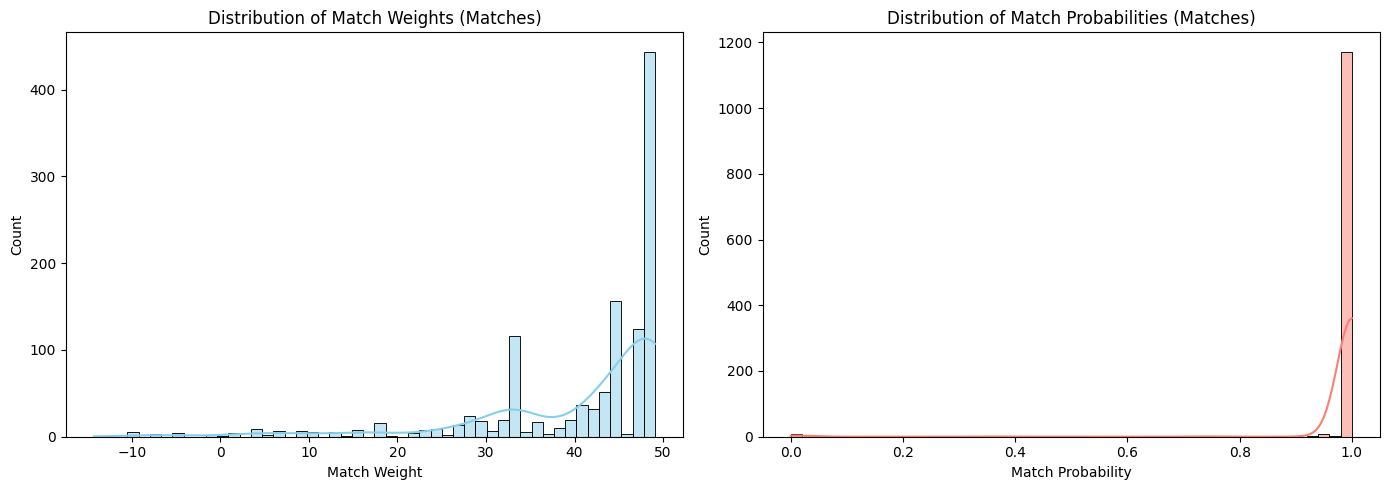

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution
sns.histplot(data=matches, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights (Matches)")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=matches, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities (Matches)")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()

In [ ]:
core_cols = ['match_probability', 'match_weight', 'uai_l', 'uai_r']
metadata_cols = ['title_l', 'title_r', 'artist_l', 'artist_r', 'album_l', 'album_r', 'number_l', 'number_r']

# 2. Extract every Bayes Factor (bf_) column generated by your settings
bf_cols = [col for col in matches.columns if col.startswith('bf_')]

# 3. Combine them into a clean, comprehensive viewing grid
inspection_df = matches[core_cols + metadata_cols + bf_cols].copy()

# Set Pandas formatting options so numbers do not truncate or convert to scientific notation
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 4. Display a snapshot of problematic cases (Low probability matches)
print("--- AMBIGUOUS/LOW CONFIDENCE CANDIDATES (Probability < 50%) ---")
low_conf = inspection_df[inspection_df['match_probability'] < 0.50].head(10)
display(low_conf)

# 5. Display a snapshot of highly confident matches (Probability = 100%)
print("\n--- HIGH CONFIDENCE MATCHES (Probability > 95%) ---")
high_conf = inspection_df[inspection_df['match_probability'] > 0.95].head(10)
display(high_conf)# 1. Define the core fields we want to inspect



--- AMBIGUOUS/LOW CONFIDENCE CANDIDATES (Probability < 50%) ---


,match_probability,match_weight,uai_l,uai_r,title_l,title_r,artist_l,artist_r,album_l,album_r,number_l,number_r,bf_artist,bf_title_lexical,bf_title_tokens,bf_album,bf_length_ms,bf_year_options,bf_number
76,0.001647,-9.243891,uai_328,uai_328,19841031,Bad,U2,U2,None,"1984-10-31: Sportpaleis Ahoy, Rotterdam, Nethe...",13.0,13.0,4602.444889,0.012693,0.004788,1.000000,5.19446,1.00000,16.863659
183,0.487021,-0.074915,uai_2514,uai_1782,Yasuragi [Tranquility] - Rurouni Kenshin Compl...,Yasuragi [Tranquility],朝倉行,朝倉紀行,Original Soundtrack Game II,Rurouni Kenshin Complete CD-BOX - Scene 9 - Or...,9.0,9.0,1685.015295,126.441283,0.004788,0.157837,5.19446,1.00000,16.863659
199,0.006369,-7.285394,uai_745,uai_745,Hair The,Hair Off,Marco Minnemann,Marco Minnemann,Off Green Mindbomb,The Green Mindbomb,5.0,5.0,4602.444889,0.012693,0.004788,0.157837,5.19446,24.62395,16.863659
202,0.006369,-7.285394,uai_510,uai_510,THE BALLAD OF MARYLOU,gThe Ballaad of Marylou,Andrew Karnavas,Andrew Karnavas,FILM NOIR,Film oir,5.0,5.0,4602.444889,0.012693,0.004788,0.157837,5.19446,24.62395,16.863659
371,0.039028,-4.621901,uai_403,uai_403,Tha-Swamp-Thang---Playmobeel,Tha Swamp Thang,Shredhead,Shredhead,None,Playmobeel,8.0,8.0,4602.444889,0.012693,0.004788,1.000000,5.19446,24.62395,16.863659
391,0.001647,-9.243891,uai_1039,uai_1039,Memo- The Natural,Meom,Randy Newman,Randy Newman,None,The Natural,6.0,6.0,4602.444889,0.012693,0.004788,1.000000,5.19446,1.00000,16.863659
400,0.006369,-7.285394,uai_361,uai_361,Wicked Horse,Mercy Laand,Sea Lion,Sea Lion,Mercy Lnd,Mercy Laand,4.0,4.0,4602.444889,0.012693,0.004788,0.157837,5.19446,24.62395,16.863659
427,0.000050,-14.284358,uai_998,uai_998,Venom - Hardstyle Top 100,eVnom,Noisecontrollers,Noisecontrollers,Best Ever,Hardstyle Top 100 - Best Ever,29.0,29.0,4602.444889,0.012693,0.004788,0.157837,1.00000,1.00000,16.863659
530,0.023135,-5.399981,uai_35,uai_35,The Way We Get By - The O.C.,The Way Way Get By,Spoon,Spoon,The Best of Season 1,The O.C. - The Best of Season 1,8.0,8.0,4602.444889,0.012693,2.262621,0.157837,1.00000,1.00000,16.863659
570,0.001647,-9.243891,uai_96,uai_96,Superhero's,Don't Fucking Care,SkaBucks,SkaBucks,None,Superhero's Finest,3.0,3.0,4602.444889,0.012693,0.004788,1.000000,5.19446,1.00000,16.863659



--- HIGH CONFIDENCE MATCHES (Probability > 95%) ---


,match_probability,match_weight,uai_l,uai_r,title_l,title_r,artist_l,artist_r,album_l,album_r,number_l,number_r,bf_artist,bf_title_lexical,bf_title_tokens,bf_album,bf_length_ms,bf_year_options,bf_number
0,1.0,49.089737,uai_283,uai_283,Sesenta y nueve,Sesenta y nueve,Macromassa,Macromassa,Puerta Heliogàbal,Puerta Heliogàbal,14.0,14.0,4602.444889,9940.639543,8811.930787,10234.166891,5.19446,24.62395,16.863659
1,1.0,49.089737,uai_43,uai_43,Cut Adrift,Cut Adrift,Hamish,Hamish,Homesick,Homesick,6.0,6.0,4602.444889,9940.639543,8811.930787,10234.166891,5.19446,24.62395,16.863659
2,1.0,39.507831,uai_605,uai_605,No Strings (I'm Fancy Free),No Strings (I'm Fancy Free),Fred Astaire & Ginger Rogers,Fred Astaire & Ginger Rogers,Fred Astaire & Ginger Rogers at RKO,Fred Astaire & Ginger Rogers at RKO,5.0,5.0,4602.444889,9940.639543,8811.930787,10234.166891,5.19446,0.03213,16.863659
3,1.0,40.391901,uai_3,uai_3,Lincoln Avenue Blues,Lincoln Avenue Blues,Butch Thompson,Butch Thompson,Lincoln Avenue Blues,Lincoln Avenue Blues,1.0,NaN,4602.444889,9940.639543,8811.930787,10234.166891,5.19446,1.00000,1.000000
4,1.0,27.033509,uai_2508,uai_3443,Old Faithful,Old Faithful,Spotnicks,The Spotnicks,to Back he Roots,Back to the Roots,4.0,4.0,1685.015295,9940.639543,8811.930787,0.157837,5.19446,1.00000,16.863659
6,1.0,44.467746,uai_943,uai_943,Face to Face,Face to Face,John Canaan,John Canaan,Our Savior's Love,Our Savior's Love,4.0,4.0,4602.444889,9940.639543,8811.930787,10234.166891,5.19446,1.00000,16.863659
7,1.0,33.105138,uai_316,uai_316,Feeling Good,Feeling Good,Andy Bey and the Bey Sisters,Andy Bey and the Bey Sisters,Andy Bey and the Bey Bey,Andy Bey and the Bey Sisters,19.0,19.0,4602.444889,9940.639543,8811.930787,0.157837,5.19446,24.62395,16.863659
8,1.0,49.089737,uai_235,uai_235,Amor de aire,Amor de aire,Almendra,Almendra,20 Éxitos,20 Éxitos,16.0,16.0,4602.444889,9940.639543,8811.930787,10234.166891,5.19446,24.62395,16.863659
9,1.0,44.467746,uai_932,uai_932,A Natural Women,A Natural Women,Aretha Franklin,Aretha Franklin,SoulMates,SoulMates,21.0,21.0,4602.444889,9940.639543,8811.930787,10234.166891,5.19446,1.00000,16.863659
10,1.0,43.018108,uai_3926,uai_3043,Christ Be With Me,Christ Be With Me,Brilliance,The Brilliance,The Brilliance,The Brilliance,11.0,11.0,1685.015295,9940.639543,8811.930787,10234.166891,5.19446,1.00000,16.863659


In [38]:
# 2. Extract every Bayes Factor (bf_) column generated by your settings
bf_cols = [col for col in non_matches.columns if col.startswith('bf_')]

# 3. Combine them into a clean, comprehensive viewing grid
inspection_df = non_matches[core_cols + metadata_cols + bf_cols].copy()

# Set Pandas formatting options so numbers do not truncate or convert to scientific notation
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 4. Display a snapshot of problematic cases (Low probability non_matches)
print("--- AMBIGUOUS/LOW CONFIDENCE CANDIDATES (Probability < 50%) ---")
low_conf = inspection_df[inspection_df['match_probability'] < 0.50].head(10)
display(low_conf)

# 5. Display a snapshot of highly confident non_matches (Probability = 100%)
print("\n--- HIGH CONFIDENCE non_matches (Probability > 95%) ---")
high_conf = inspection_df[inspection_df['match_probability'] > 0.95].head(10)
display(high_conf)

--- AMBIGUOUS/LOW CONFIDENCE CANDIDATES (Probability < 50%) ---


,match_probability,match_weight,uai_l,uai_r,title_l,title_r,artist_l,artist_r,album_l,album_r,number_l,number_r,bf_artist,bf_title_lexical,bf_title_tokens,bf_album,bf_length_ms,bf_year_options,bf_number
12,1.263748e-11,-36.203500,uai_14,uai_348,"Concerto No. 4, BWV 1049: III. Presto",Concerto for Piano and Orchestra No. 9 in E-fl...,Johann Sebastian Bach,Wolfgang Amadeus Mozart,"Brandenburg Concertos 4, 5 & 6 (Musica Antiqua...",Spectacular Classics,3.0,3.0,0.090234,0.012693,0.004788,0.157837,0.012862,1.000000,16.863659
73,1.097476e-05,-16.475436,uai_372,uai_372,I Take a Lot of Pride in What I Am,Swingin' Doors,Merle Haggard,Merle Haggard,Steve Austin's Stone Cold Country,The Kings & Queens of Country,4.0,4.0,4602.444889,0.012693,0.004788,0.157837,5.194460,0.042158,16.863659
84,5.103886e-09,-27.545757,uai_1840,uai_267,Konzertetüde Nr. 2 G 145 „Gnomenreigen“,"Konzert für Gitarre, Streicher und Continuo C-...",F. Liszt,Antonio Vivaldi,Romantische Klavierwerke,Hightech Konzert,2.0,2.0,0.090234,0.012693,0.004788,0.157837,5.194460,1.000000,16.863659
86,4.060481e-13,-41.163415,uai_5626,uai_5074,"Don't Cry for Me Argenttina (Pre-Madonna 7f"" e...",Don't Stop the Carnival,Mike Flowers Pops,Davy Graham,Don't Cry for Me Argentina,The Guitar Player,1.0,1.0,0.090234,0.012693,0.004788,0.157837,0.012862,0.032130,16.863659
104,6.445842e-07,-20.565127,uai_14,uai_14,"Prelude And Fugue In A Minor, BWV 894: Prelude",Konzert für Cembalo f-moll BWV 1056: II. Largo,Johann Sebastian Bach,Johann Sebastian Bach,The Complete Keyboard Works Of J.S. Bach On Co...,Orchester-Suiten,9.0,9.0,4602.444889,0.012693,0.004788,0.157837,0.012862,1.000000,16.863659
123,2.964029e-13,-41.617506,uai_3436,uai_2358,Voodoo Rhythm,Voodoo Lovers,Meteors,Hurricäde,From Zorch With Lov,Hurricäde,1.0,1.0,0.090234,0.012693,0.004788,0.157837,0.009389,0.032130,16.863659
131,2.411925e-06,-18.661380,uai_1248,uai_782,Little Man,Little for a Lot,K’s Choice,Spires That in the Sunset Rise,Not an Addict,Four Winds the Walker,3.0,3.0,0.090234,0.012693,2.262621,0.157837,5.194460,1.000000,16.863659
146,9.787153e-06,-16.640665,uai_57,uai_57,"Symphony No. 3 in E-flat major, Op. 55 ""Sinfon...","Sonata for piano No. 1 in F minor, Op 2 No. 1:...",Ludwig van Beethoven,Ludwig van Beethoven,The Symphonies,The Early Sonatas,3.0,3.0,4602.444889,0.012693,2.262621,0.157837,0.012862,0.032130,16.863659
150,2.071079e-08,-25.525042,uai_14,uai_14,"Invention 1 in C major, BWV 772","Passacaglia and Fugue in C minor, S.582",Johann Sebastian Bach,Johann Sebastian Bach,The Two and Three Part Inventions,The 24 Organ Preludes and Fugues With Selected...,1.0,1.0,4602.444889,0.012693,0.004788,0.157837,0.012862,0.032130,16.863659
151,6.445842e-07,-20.565127,uai_14,uai_14,"Kantate, BWV 4 ""Christ lag in Todesbanden"": V....",Sonata for Violin and Harpsichord No. 5 in F m...,Johann Sebastian Bach,Johann Sebastian Bach,"Edition Bachakademie, Volume 2: Cantatas BWV 4...",Sonatas for Violin and Harpsichord (feat. viol...,5.0,5.0,4602.444889,0.012693,0.004788,0.157837,0.012862,1.000000,16.863659



--- HIGH CONFIDENCE non_matches (Probability > 95%) ---


,match_probability,match_weight,uai_l,uai_r,title_l,title_r,artist_l,artist_r,album_l,album_r,number_l,number_r,bf_artist,bf_title_lexical,bf_title_tokens,bf_album,bf_length_ms,bf_year_options,bf_number
333,1.000000,23.869459,uai_199,uai_5093,Perfect Day,Perfect Day,Cascada,Chris Whitley,Perfect Day,Perfect Day,6.0,6.0,0.090234,9940.639543,8811.930787,10234.166891,5.194460,0.032130,16.863659
377,1.000000,35.808803,uai_770,uai_770,[silence],[silence],Tobacco,Tobacco,Ultima II Massage,Ultima II Massage,65.0,76.0,4602.444889,9940.639543,8811.930787,10234.166891,5.194460,1.000000,0.041721
394,0.978496,5.507886,uai_3046,uai_2839,[untitled],[untitled],神神聖かまってちゃん,S-Max,楽しいね,StreetleNvel Surrealizm E.P.,11.0,11.0,0.090234,9940.639543,8811.930787,0.157837,1.000000,0.032130,16.863659
525,0.998510,9.388251,uai_5398,uai_3041,Introduction,Introducción,David Isay,Willie Colón,"Holding On: Dreamers, Visionaries, Eccentrics ...",Asalto Navideño,1.0,1.0,0.090234,4703.675977,8811.930787,0.157837,1.000000,1.000000,16.863659
638,0.999864,12.844775,uai_5254,uai_661,Amazing Grace,Amazing Grace,Mahalia Jackson,Yes,Christmas Gospel,Going for theO ne,8.0,8.0,0.090234,9940.639543,8811.930787,0.157837,5.194460,1.000000,16.863659
709,0.995787,7.884860,uai_3514,uai_3303,Nada,Nada,Zo,Robert Rich,AOL: Dejando huellas,Humidity,2.0,2.0,0.090234,9940.639543,8811.930787,0.157837,5.194460,0.032130,16.863659
814,1.000000,22.802006,uai_992,uai_992,"En dans med drager, del 502","En dans med drager, del 219",George R. R. Martin indlæst af Martin Greis-Ro...,George R. R. Martin indlæst af Martin Greis-Ro...,En dans med drager,En dans med drager,502.0,219.0,4602.444889,4703.675977,2.262621,10234.166891,5.194460,1.000000,0.041721
889,0.999294,10.467801,uai_5398,uai_3794,Introduction,Introduction,David Isay,World Standard,"Holding On: Dreamers, Visionaries, Eccentrics ...",Country Gazette,1.0,1.0,0.090234,9940.639543,8811.930787,0.157837,1.000000,1.000000,16.863659
1191,0.996786,8.276723,uai_2119,uai_2321,Circles,Circles,Captain & Tennille,Five Knuckle,20th Century Masters: The Millennium Collectio...,Rock Sound: Armed & Dangerous,8.0,8.0,0.090234,9940.639543,8811.930787,0.157837,5.194460,0.042158,16.863659
1337,0.986640,6.206546,uai_819,uai_819,Prisoner of Dub,Prisoner of Dub,Sub Oslo,Sub Oslo,Babylon Is Ours: The USA in Dub,Sub Signals - Volume 1,10.0,6.0,4602.444889,9940.639543,8811.930787,0.157837,0.012862,0.032130,0.041721


In [29]:

# ==========================================
# STEP 1: Discover Splink's Internal Dataset Names
# ==========================================
# Get the exact keys Splink uses internally to label the left and right datasets
dataset_names = list(linker._input_tables_dict.keys())
print(f"DEBUG: Splink recognizes your datasets as: {dataset_names}")

# Assign them cleanly based on their registration sequence
internal_name_df1 = dataset_names[0]
internal_name_df2 = dataset_names[1]


# ==========================================
# STEP 2: Standardise and Extract Common Identifiers
# ==========================================
# Get common IDs and ensure they are read purely as identical string types
ids_df1 = df1[['CID']].copy().rename(columns={'CID': 'CID_l'})
ids_df2 = df2[['CID']].copy().rename(columns={'CID': 'CID_r'})

raw_matches = ids_df1.merge(ids_df2, left_on='CID_l', right_on='CID_r')


# ==========================================
# STEP 3: Enforce Exact Splink Alphabetical Left-Right Sort Order
# ==========================================
labels_df = pd.DataFrame()
labels_df["CID_l"] = raw_matches["CID_l"]
labels_df["CID_r"] = raw_matches["CID_r"]
labels_df["source_dataset_l"] = internal_name_df1
labels_df["source_dataset_r"] = internal_name_df2
labels_df["clerical_match_score"] = 1.0

# Splink drops labels if concat(source_l, id_l) > concat(source_r, id_r)
concat_l = labels_df["source_dataset_l"] + "-__-" + labels_df["CID_l"].to_string()
concat_r = labels_df["source_dataset_r"] + "-__-" + labels_df["CID_r"].to_string()
swap_mask = concat_l > concat_r

if swap_mask.any():
    # Correct source datasets orientation
    labels_df.loc[swap_mask, ["source_dataset_l", "source_dataset_r"]] = \
        labels_df.loc[swap_mask, ["source_dataset_r", "source_dataset_l"]].values
    # Correct corresponding ID orientation
    labels_df.loc[swap_mask, ["CID_l", "CID_r"]] = \
        labels_df.loc[swap_mask, ["CID_r", "CID_l"]].values


# ==========================================
# STEP 4: Safely Overwrite and Register Table Pointers
# ==========================================
try:
    linker.misc.query_sql("DROP TABLE IF EXISTS my_ground_truth_labels")
except Exception:
    pass

labels_table = linker.table_management.register_labels_table(labels_df, overwrite=True)
print(f"Success: Registered {len(labels_df)} ground-truth rows with Splink's structural format.")


# ==========================================
# STEP 5: Force Prediction & Extract Accuracy Metrics
# ==========================================
# Ensure a prediction pass has run so intermediate tables are active
print("Calculating link pairs...")
pred = linker.inference.predict() 

# Extract the metrics
try:
    roc_metrics_df = linker.evaluation.accuracy_analysis_from_labels_table(
        labels_table, 
        output_type="table",
        add_metrics=["f1", "accuracy"]
    ).as_pandas_dataframe()
    
    print(f"Evaluation succeeded! Rows generated: {len(roc_metrics_df)}")
except Exception as err:
    print(f"Failed during evaluation compilation: {err}")


'CREATE TABLE __splink__df_sql_query_a6458914f AS 
DROP TABLE IF EXISTS my_ground_truth_labels' contains unsupported syntax. Falling back to parsing as a 'Command'.


Blocking time: 0.07 seconds


DEBUG: Splink recognizes your datasets as: ['__splink__input_table_0', '__splink__input_table_1']
Success: Registered 1266 ground-truth rows with Splink's structural format.
Calculating link pairs...


Predict time: 0.13 seconds


Evaluation succeeded! Rows generated: 113


In [31]:
linker.evaluation.accuracy_analysis_from_labels_table(
    labels_table, 
    add_metrics=["f1", "accuracy"],
    output_type="threshold_selection"
)


alt.HConcatChart(...)

In [32]:
left_counts  = df1_clean["uai"].value_counts()   # Series: id → frequency in df1
right_counts = df2_clean["uai"].value_counts()   # Series: id → frequency in df2

agg_df = (
    df_results[
        ['uai_l', 'uai_r','match_probability']
    ]
    .groupby(['uai_l', 'uai_r'], as_index=False, dropna=False)
    .agg({'match_probability': sum})
)

agg_df

/tmp/ipykernel_6850/105722358.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'match_probability': sum})


,uai_l,uai_r,match_probability
0,uai_0,uai_0,1.000000
1,uai_1,uai_1,1.000000
2,uai_10,uai_10,1.000000
3,uai_100,uai_100,1.000000
4,uai_1000,uai_1000,1.000000
...,...,...,...
1318,uai_994,uai_994,1.000000
1319,uai_995,uai_995,1.000000
1320,uai_996,uai_996,1.000000
1321,uai_997,uai_997,0.999185


In [33]:
unique_l = left_counts.index
unique_r = right_counts.index

# Cartesian product of the observed ids (still a DataFrame)
pair_keys = pd.MultiIndex.from_product(
    [unique_l, unique_r],
    names=["uai_l", "uai_r"]
).to_frame(index=False)

# Attach the left and right counts
pair_keys = pair_keys.merge(
    left_counts.rename("left_count"),
    left_on="uai_l",
    right_index=True,
    how="left"
).merge(
    right_counts.rename("right_count"),
    left_on="uai_r",
    right_index=True,
    how="left"
)

# Pair‑specific denominator = left_count × right_count
pair_keys["pair_size"] = pair_keys["left_count"] * pair_keys["right_count"]

# -------------------------------------------------
# 4️⃣  Join the aggregated probabilities to the pair‑specific sizes
# -------------------------------------------------
# ---------------------------------------------------------------------------
# 4️⃣ Join the aggregated probabilities using an INNER join to drop NaNs
# ---------------------------------------------------------------------------
norm_df = pair_keys.merge(
    agg_df,
    on=["uai_l", "uai_r"],
    how="inner" # Drops any unobserved pairs instantly
)

# Calculate your normalized metrics only on the pairs that survived
norm_df["norm_match_prob"] = norm_df["match_probability"] / norm_df["pair_size"]

norm_df


,uai_l,uai_r,left_count,right_count,pair_size,match_probability,norm_match_prob
0,uai_14,uai_14,22,24,528,1.094172e+01,2.072296e-02
1,uai_14,uai_348,22,12,264,1.304353e-11,4.940732e-14
2,uai_14,uai_5471,22,1,22,5.103886e-09,2.319948e-10
3,uai_348,uai_14,13,24,312,2.527497e-11,8.100952e-14
4,uai_348,uai_348,13,12,156,2.000587e+00,1.282427e-02
...,...,...,...,...,...,...,...
1318,uai_1510,uai_4327,1,1,1,2.964029e-13,2.964029e-13
1319,uai_711,uai_45,1,1,1,2.964029e-13,2.964029e-13
1320,uai_711,uai_711,1,1,1,1.000000e+00,1.000000e+00
1321,uai_658,uai_658,1,1,1,1.000000e+00,1.000000e+00


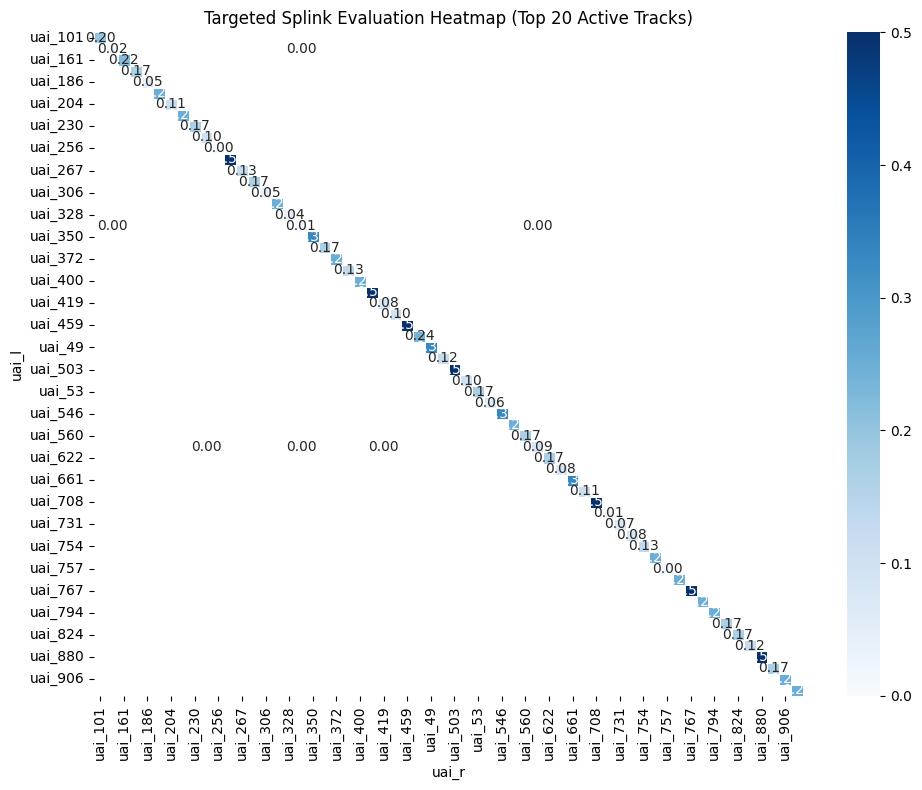

In [34]:
# 1. Identify the most active ground truth track IDs
top_entities = norm_df[norm_df['uai_l'] == norm_df['uai_r']].nlargest(60, 'pair_size')['uai_l']

# 2. Slice the matrix strictly to interactions involving these top entities
dense_subset = norm_df[norm_df['uai_l'].isin(top_entities) & norm_df['uai_r'].isin(top_entities)]

# 3. Pivot ONLY this small dense subset (Safe from memory drops)
mat_sub = dense_subset.pivot(index='uai_l', columns='uai_r', values='norm_match_prob')

# 4. Render the targeted heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    mat_sub,
    cmap='Blues',           # Sequential map works better here since numbers are 0 to 1
    mask=mat_sub.isna(),
    linewidths=.5,
    annot=True,             # Write numbers inside cells for explicit tracking
    fmt=".2f"
)
plt.title('Targeted Splink Evaluation Heatmap (Top 20 Active Tracks)')
plt.tight_layout()
plt.show()


In [35]:
import numpy as np
import pandas as pd

# 1. Establish the absolute baseline of true connections in your ground truth
# (Every unique track ID matching with itself)
total_possible_true_matches = len(left_counts.index.intersection(right_counts.index))

# 2. Generate a spectrum of threshold checkpoints
thresholds = np.linspace(0.05, 0.95, 19)
pr_results = []

for t in thresholds:
    # Flag predicted pairs that clear the current normalization threshold
    predicted_pairs = norm_df[norm_df['norm_match_prob'] >= t]
    
    # Calculate True Positives (On the diagonal)
    tp = len(predicted_pairs[predicted_pairs['uai_l'] == predicted_pairs['uai_r']])
    
    # Calculate False Positives (Off the diagonal)
    fp = len(predicted_pairs[predicted_pairs['uai_l'] != predicted_pairs['uai_r']])
    
    # Deriving structural evaluation metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / total_possible_true_matches if total_possible_true_matches > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    pr_results.append({
        'Threshold': round(t, 2),
        'True_Positives': tp,
        'False_Positives': fp,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1_Score': round(f1, 4)
    })

# Convert to tracking DataFrame for analysis
pr_curve_df = pd.DataFrame(pr_results)
display(pr_curve_df)


,Threshold,True_Positives,False_Positives,Precision,Recall,F1_Score
0,0.05,906,265,0.7737,0.8596,0.8144
1,0.10,899,261,0.7750,0.8529,0.8121
2,0.15,889,260,0.7737,0.8435,0.8071
3,0.20,878,258,0.7729,0.8330,0.8018
4,0.25,865,254,0.7730,0.8207,0.7961
5,0.30,864,251,0.7749,0.8197,0.7967
6,0.35,855,246,0.7766,0.8112,0.7935
7,0.40,854,241,0.7799,0.8102,0.7948
8,0.45,854,240,0.7806,0.8102,0.7952
9,0.50,792,215,0.7865,0.7514,0.7686


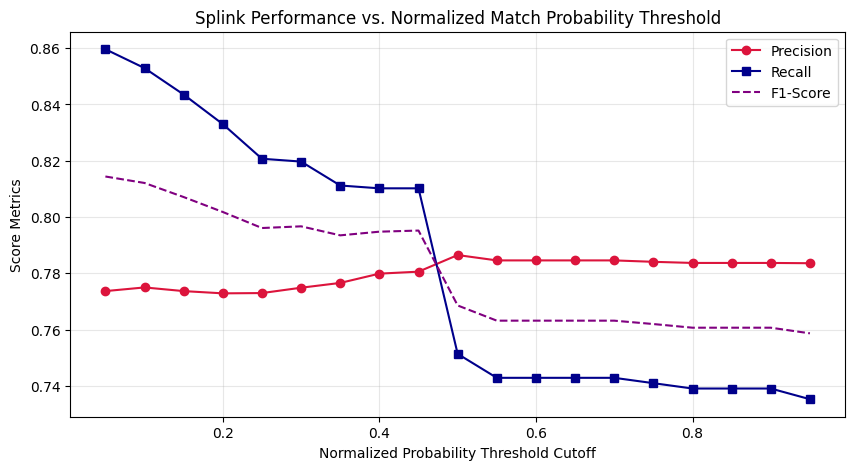

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(pr_curve_df['Threshold'], pr_curve_df['Precision'], label='Precision', marker='o', color='crimson')
plt.plot(pr_curve_df['Threshold'], pr_curve_df['Recall'], label='Recall', marker='s', color='darkblue')
plt.plot(pr_curve_df['Threshold'], pr_curve_df['F1_Score'], label='F1-Score', linestyle='--', color='purple')

plt.title('Splink Performance vs. Normalized Match Probability Threshold')
plt.xlabel('Normalized Probability Threshold Cutoff')
plt.ylabel('Score Metrics')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [41]:
global_matches = norm_df[norm_df["uai_l"] == norm_df["uai_r"]]
global_matches.sort_values(by="norm_match_prob")

,uai_l,uai_r,left_count,right_count,pair_size,match_probability,norm_match_prob
1109,uai_305,uai_305,1,1,1,5.123835e-11,5.123835e-11
540,uai_301,uai_301,1,1,1,1.164081e-09,1.164081e-09
59,uai_256,uai_256,3,2,6,6.445842e-07,1.074307e-07
245,uai_218,uai_218,1,1,1,1.311072e-07,1.311072e-07
1023,uai_1038,uai_1038,1,1,1,1.610260e-06,1.610260e-06
...,...,...,...,...,...,...,...
1290,uai_704,uai_704,1,1,1,1.000000e+00,1.000000e+00
1278,uai_108,uai_108,1,1,1,1.000000e+00,1.000000e+00
152,uai_543,uai_543,1,1,1,1.000000e+00,1.000000e+00
150,uai_744,uai_744,1,1,1,1.000000e+00,1.000000e+00


In [42]:
global_non_matches = norm_df[norm_df["uai_l"] != norm_df["uai_r"]]
global_non_matches.sort_values(by="norm_match_prob")

,uai_l,uai_r,left_count,right_count,pair_size,match_probability,norm_match_prob
23,uai_659,uai_1970,6,1,6,2.964029e-13,4.940048e-14
1,uai_14,uai_348,22,12,264,1.304353e-11,4.940732e-14
35,uai_2192,uai_843,4,1,4,2.964029e-13,7.410073e-14
3,uai_348,uai_14,13,24,312,2.527497e-11,8.100952e-14
74,uai_1091,uai_121,2,2,4,4.060481e-13,1.015120e-13
...,...,...,...,...,...,...,...
168,uai_5102,uai_2233,1,1,1,1.000000e+00,1.000000e+00
162,uai_3313,uai_3231,1,1,1,1.000000e+00,1.000000e+00
223,uai_4169,uai_4622,1,1,1,1.000000e+00,1.000000e+00
1213,uai_2484,uai_6056,1,1,1,1.000000e+00,1.000000e+00
